### This notebook is an example of using OpenDLTS_DataHandler to process current transient data

In [1]:
%matplotlib widget
import sys
sys.path.append("..")
import OpenDLTS_DataHandler as oddh
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from pathlib import Path

Required format for raw data:

In [2]:
_tempdata = np.loadtxt('./data/IDLTS_data.transdata')
_tempdata
#_tempdata[0,1:] is the measurement time series of the data, unit: [s]
#_tempdata[1:,0] is the measurement temperature of the data, unit: [K]
#_tempdata[i,1:] is the transient data at the corresponding temperature _tempdata[1:,i], unit: [F/A/V]

array([[0.0000000e+00, 2.9866667e-05, 3.4133333e-05, ..., 5.9989333e-02,
        5.9993600e-02, 5.9997867e-02],
       [2.0000000e+02, 7.4519921e-04, 7.4103364e-04, ..., 5.5469037e-04,
        5.5460224e-04, 5.5461482e-04],
       [2.0200000e+02, 7.6565659e-04, 7.6162850e-04, ..., 5.7664141e-04,
        5.7668262e-04, 5.7655771e-04],
       ...,
       [4.4601999e+02, 1.0931162e-03, 1.0887474e-03, ..., 7.9117797e-04,
        7.9131091e-04, 7.9133036e-04],
       [4.4798001e+02, 1.0924063e-03, 1.0877415e-03, ..., 7.9098984e-04,
        7.9082092e-04, 7.9098658e-04],
       [4.5001999e+02, 1.0910062e-03, 1.0860476e-03, ..., 7.9077686e-04,
        7.9092721e-04, 7.9108943e-04]], shape=(126, 14057))

In [3]:
data = oddh.Data_Loader(
    transient_data = './data/IDLTS_data.transdata',
    raw_data_scaling_factor = 1.0,# Scale the data when importing, if the data is not in standard units such as [F/A/V]
    data_scaling_factor = 1e6,# Scale according to the magnitude of the data. The scaled data will be directly applied to the subsequent fitting process. Data that is too small/large after scaling may cause non-convergence. Generally, it is 1e12 for capacitance data in pF magnitude, and 1e6 for current data in μA magnitude
    data_type = 'I',# Determine the type of data, capacitance data is 'C', current data is 'I', voltage data is 'V', this will affect the display of units in the figure, does not affect data fitting
    #data_x_type = 'Time',# Determine the x type of data, generally transient data, so default is fine
    #condition_type = 'Temperature',# Determine the measurement condition of the data, generally measured at different temperatures, so default is fine
    logging_level = 'info',
    logging_file = None,# If you need to write the log to a file, specify the path string
    logging_file_clear = False,# Clear the log under the logging_file path when importing data
)

(ODDH) 2026-03-05 16:40:03,483 - __oddh__ - INFO - Data loaded from file: /mnt/userdata/yutao/jupyter/LDLTS-Tao/OpenDLTS_DataHandler/examples/data/IDLTS_data.transdata


# The OpenDLTS_DataHandler module provides ipywidgets-based widgets for data visualization
### If you want to preprocess the data, call oddh.Widgets.Data_Viewer_Box

In [4]:
_temp_ui = oddh.Widgets.Data_Viewer_Box(data)

### If you want to view the traditional DLTS spectrum of the data, call oddh.Widgets.DLTS_Viewer_Box
Common DLTS spectrum plotting methods are based on Correlation function

In [5]:
_temp_ui = oddh.Widgets.DLTS_Viewer_Box(data)

### If you want to perform LDLTS fitting on the data, call oddh.Widgets.LDLTS_Viewer_Box
LDLTS converts the time domain signal $\mathbf{I(t,T)}$ to the time constant spectrum (TCS) $\mathbf{F(\tau,T)}$ by creating a kernel matrix $\mathbf{A}$
\begin{equation}
    \mathrm{\mathop{arg\ min}\limits_{\mathbf{F}}\ \left\{ \left|\left|\mathbf{I}-\mathbf{A}\times\mathbf{F}\right|\right|_2^2 +\lambda \cdot L \right\}}
\end{equation}
Before fitting, you can use the data_space method to logarithmically interpolate the transient data in the time domain, thereby reducing the solving pressure

In [6]:
# The actual Ns may not be equal to the set num, refer to the file _ReSampleFromTimeArray.py for detailed algorithms
ldlts_data = data.data_space(num=100,space='log')
ui = oddh.Widgets.LDLTS_Viewer_Box(
    dlts_data = ldlts_data,
    Ns = 500,
    s0 = 1e-1,
    s1 = 1e5
)

(ODDH) 2026-03-05 16:40:14,646 - __oddh__ - INFO - Data loaded from provided dictionary.
(ODDH) 2026-03-05 16:40:14,646 - __oddh__ - INFO - New Data resampled to 100 points in log space.
(ODDH) 2026-03-05 16:40:14,648 - __oddh__.LDLTS_Viewer_Box - INFO - LDLTS Method Initialized with Ns=500, s0=1.0E-01, s1=1.0E+05


### After ui is instantiated, attributes for multiple fitting methods L1/D2/SR/SRL1/L2 will be created
Here we use the most commonly used L1 method. Its attribute C is the transient data (scaled), attribute A is the kernel matrix, and attribute A_extended adds a constant 1 to the first column of A for fitting the DC bias of the signal

In [7]:
print(f'C.shape={ui.L1.C.shape}')
print(f'A.shape={ui.L1.A.shape}')
print(f'A_extended.shape={ui.L1.A_extended.shape}')
print(f'A_extended[:,0]={ui.L1.A_extended[:,0]}')

C.shape=(125, 98)
A.shape=(98, 500)
A_extended.shape=(98, 501)
A_extended[:,0]=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]


### Use the solve method to solve

In [8]:
polarity='negative'# Constrain data to be composed of negative TCS
material='sic'# Specify material parameters used to calculate activation energy and capture cross section
# Specify the majority carrier type of the material used to calculate activation energy and capture cross section
# For P-type. If TCS is positive, it is considered a majority (hole) trap, and hole-related parameters are used to calculate its capture cross section; if TCS is negative, it is considered a minority (electron) trap, and electron-related parameters are used to calculate its capture cross section;
# For N-type. If TCS is positive, it is considered a majority (electron) trap, and electron-related parameters are used to calculate its capture cross section; if TCS is negative, it is considered a minority (hole) trap, and hole-related parameters are used to calculate its capture cross section.
material_doping_type='P'
solve_arg = {}
solve_arg['L1'] = {
    "Ti_list":np.arange(len(ui.L1.T)),# Specify the index list of temperatures, data at these temperatures will be fitted, here all temperatures are used
    "polarity":polarity,
    "lambda1":1e-6,# Specify regularization parameter
    "verbose":True,
    "skip_solved":True,
    #"solver":'MOSEK',
    "solver":'GUROBI',# Specify solver, GUROBI/MOSEK/COPT require application and configuration of license, students can apply for free
    #"solver":'COPT',
    #"solver_params":{'eps':1e-9,'canon_backend':cp.SCIPY_CANON_BACKEND},
    "solver_params":{'Threads':0,'Presolve':-1,'BarOrder':0,'Method':2,'canon_backend':cp.SCIPY_CANON_BACKEND},
    'f_scaling_by_C':False,
    'enable_irls_mode':False,
    'irls_weight':1,
    'arg_lists_use_cp_parameter':['lambda1']
}
ui.L1.solve(**solve_arg['L1'])

(ODDH) 2026-03-05 16:40:19,276 - __oddh__.L1 - INFO - L1 solve: build new problem
(ODDH) 2026-03-05 16:40:19,278 - __oddh__.L1 - INFO - #CVXPY Output#: ===============================================================================
(ODDH) 2026-03-05 16:40:19,278 - __oddh__.L1 - INFO - #CVXPY Output#:                                      CVXPY                                     
(ODDH) 2026-03-05 16:40:19,278 - __oddh__.L1 - INFO - #CVXPY Output#:                                      v1.7.2                                    
(ODDH) 2026-03-05 16:40:19,278 - __oddh__.L1 - INFO - #CVXPY Output#: ===============================================================================
(CVXPY) 2026-03-05 16:40:19,278 - __cvxpy__ - INFO - Your problem has 62625 variables, 62500 constraints, and 1 parameters.
(CVXPY) 2026-03-05 16:40:19,279 - __cvxpy__ - INFO - It is compliant with the following grammars: DCP, DQCP
(CVXPY) 2026-03-05 16:40:19,279 - __cvxpy__ - INFO - CVXPY will first compile your pro

### After solving, return to the ui Cell or recall like the Cell below
#### Then click Refresh to visualize the data.
#### All results after solve are in the list ui.L1.solve_history. solve_index in ui is used to visualize a specific solution result. Many operations in ui require clicking Refresh to implement
#### The bar widget below solve_index is used to specify the experimental data under the corresponding temperature index. Dragging this widget will update the two graphs above in real time. The upper left graph is the comparison of experimental/fitted transient data, and the upper right graph is the time constant spectrum TCS of the fitted data at a single temperature
#### The left graph of the two graphs below is the time constant spectrum TCS of the fitted data at all temperatures, and the lower right graph is the graph after TCS is converted to Arrhenius coordinates
#### The lower right graph can select points by dragging with the left/right mouse button. For points with the same temperature, the centroid of their ordinates will be automatically calculated. Thereby calculating the corresponding activation energy and capture cross section.
#### Material and Doping Type in ui are related to the calculation result of the capture cross section in the lower right graph. Please make sure to select correctly. After selection, you need to click Refresh.

In [9]:
ui.box

### Typical Arrh fitting results are:
![Arrh_Plot_Fitting_Result](pic/arrh_plot_example.png)

Or you can manually call the method plot_arrh

Cross Section & Activation Energy Calculation Based On Material: N-type SiC with Temperature Coeff.: 2


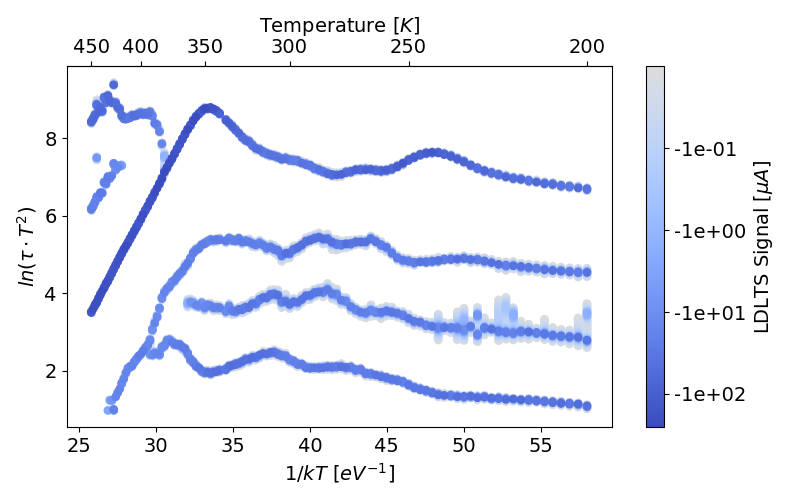

In [10]:
ui.L1.plot_arrh(
    solve_index = -1,
    c_abs_min = 1e-02,
    c_polarity = 'negative',
    material = 'SiC',
    dopant_species = 'N',
    colorbar_scale = 'log',
    point_scale = 30,
    lw = 0.8,
    peak_point_scale = 30,
    peak_lw = 0.8,
    line_lw = 1.0,
    power_T = 2,
    cmap = 'coolwarm',
    data_from_irls = False,
    use_time_constant = True,
    figsize = (8, 5),
    return_widgets = False,
    fs = 14,
)

In [ ]:
ui.L1.arrh_plotter.get_group()

### After calling the plot_arrh method, the arrh_plotter attribute will be created under the corresponding method instance. Calling the get_group method of this attribute can group the selected points and the fitted line
### Typical results after grouping are shown in the figure below:
![Arrh_Plot_Fitting_Result](pic/arrh_plot_example2.png)

### The grouped data is in the list trap_groups

In [24]:
ui.L1.arrh_plotter.trap_groups